## Model na predikciu DST za pomoci použitia atribútu DST o 1 hodinu dopredu

Súbor: prediction_DST+1_6.ipynb

Program: Hospodárska informatika

Vypracovala: Bc. Terézia Drengubiaková

Diplomov práca: : Metódy strojového učenia pre včasnú predikciu geomagnetických búrok

Vedúci diplomovej práce: doc. Ing. Peter Butka, PhD.

Konzultanti: Ing. Viera Krešňáková, PhD., RNDr. Šimon Mackovjak, PhD.

### Import knižníc

In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Model
from keras.layers import Dense, Input, LSTM, Flatten, TimeDistributed, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, mean_squared_error, mean_absolute_error

2026-04-16 23:06:17.732699: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Načítanie dát, odstránenie na hodnôt, určenie predikovaného atribútu

In [2]:
# dĺžka vstupného okna a predikovaný čas
shift = 6
y_col = f"DST+{shift}"

n_input = 48
atr_count = 2

In [3]:
file_path = "../../../0_datasety/test_omni.csv"
file_path2 = "../../../0_datasety/train_omni.csv"

train = pd.read_csv(file_path2)
test = pd.read_csv(file_path)

In [4]:
features = ['time1', 'DST', 'v', y_col]
test = test[features]
train = train[features]
train['time1']=pd.to_datetime(train['time1'])
test['time1']=pd.to_datetime(test['time1'])
predicators = ["DST", "v"]

valid_size = int(len(train) * 0.2)
valid = train.iloc[-valid_size:,:].copy()
train = train.iloc[:-valid_size,:].copy()

y_train = train[y_col].values.copy()
X_train = train[predicators].values.copy()
y_val = valid[y_col].values.copy()
X_val = valid[predicators].values.copy()
y_test = test[y_col].values.copy()
X_test = test[predicators].values.copy()

### Definícia premenných a vytvorenie dátových generátorov

In [5]:
b_size = 256  

train_generator = TimeseriesGenerator(X_train, y_train, length=n_input, batch_size=b_size)
val_generator = TimeseriesGenerator(X_val, y_val, length=n_input, batch_size=b_size)
test_generator = TimeseriesGenerator(X_test, y_test, length=n_input, batch_size=256)

In [6]:
print("Počet batchov: ", len(train_generator))
print("Každý batch má features (X zložku) a labels (y zložku): ", len(train_generator[0]))
print("Dĺžka X zložky batchu: ", len(train_generator[0][0]))
print("Dĺžka y zložky batchu (počet meraní v batchi): ",len(train_generator[0][1]))
print("Počet riadkov braných do úvahy pre jedno meranie (koľko sa pozerá dozadu): ", len(train_generator[0][0][0]))

Počet batchov:  896
Každý batch má features (X zložku) a labels (y zložku):  2
Dĺžka X zložky batchu:  256
Dĺžka y zložky batchu (počet meraní v batchi):  256
Počet riadkov braných do úvahy pre jedno meranie (koľko sa pozerá dozadu):  48


### Vytvorenie modelu

In [7]:
inputs = Input(shape=(n_input,atr_count))
c = Bidirectional(LSTM(128, return_sequences=True, dropout=0.1,recurrent_dropout=0.1))(inputs)
c = LSTM(128, return_sequences=True)(c)
c = TimeDistributed(Dense(1, activation='linear'))(c)
output = Flatten()(c)
output = Dense(1, activation='linear')(output)
model = Model(inputs=inputs, outputs=output)
model.compile(loss='mse', optimizer='adam', metrics=["mae"])
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 48, 2)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 48, 256)             │         134,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 48, 128)             │         197,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 48, 1)               │             129 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 48)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 331,442 (1.26 MB)

 Trainable params: 331,442 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
model_path = f'../../train automate/models/{y_col}_{n_input}H_V.keras'
checkpoint = ModelCheckpoint(model_path, monitor='val_mae', verbose=1, save_best_only=True, mode='min')
early = EarlyStopping(monitor="val_mae", mode="min", patience=25)
callbacks_list = [checkpoint, early]

### Trénovanie

In [9]:
#uncomment to train new model
#history = model.fit(train_generator, validation_data=val_generator, epochs=200, verbose=1, callbacks = callbacks_list)

### Načítanie najlepšieho modelu

In [10]:
model = keras.models.load_model(model_path)

### Vytvorenie predikcií

In [11]:
y_pred = model.predict(test_generator)

/opt/conda/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/759 ━━━━━━━━━━━━━━━━━━━━ 9:15 733ms/step

  2/759 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step  

  3/759 ━━━━━━━━━━━━━━━━━━━━ 55s 74ms/step

  4/759 ━━━━━━━━━━━━━━━━━━━━ 56s 74ms/step

...

756/759 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

757/759 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

758/759 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

759/759 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

759/759 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step


### Nájdenie optimálneho thresholdu na validačnej sade

In [12]:
# y_test je o n_input dlhší – odsekneme prvých n_input hodnôt:
aligned_y_test = y_test[n_input:]
residuals = aligned_y_test.flatten() - y_pred.flatten()

In [13]:
residuals_series = pd.Series(residuals, index=test['time1'].iloc[n_input:])

In [14]:
y_val_pred = model.predict(val_generator)
true_labels_val = np.where(y_val[n_input:] <= -20, 1, 0)  

def calculate_mcc(y_true, y_pred):
    return matthews_corrcoef(y_true, y_pred)

thresholds = np.arange(-10, -40, -0.1)
mcc_scores = []

for thresh in thresholds:
    predictions = np.where(y_val_pred <= thresh, 1, 0)
    mcc = calculate_mcc(true_labels_val, predictions)
    mcc_scores.append(mcc)

best_threshold_mcc = thresholds[np.argmax(mcc_scores)]
best_mcc = max(mcc_scores)

print("Best Threshold for MCC on Validation Set:", best_threshold_mcc)
print("Best MCC on Validation Set:", best_mcc)

# Refactored variable name for consistent use
CLASSIFICATION_THRESHOLD = round(best_threshold_mcc, 1)

  1/224 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step

  2/224 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step

  3/224 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step

  4/224 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step

  5/224 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step

...

222/224 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

224/224 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step


Best Threshold for MCC on Validation Set: -20.199999999999964
Best MCC on Validation Set: 0.7316941244583274


### Výpočet metrík, vykreslenie grafu predikcie a uloženie predikcií

In [15]:
y_pred_binary_lstm = np.where(y_pred <= CLASSIFICATION_THRESHOLD, 1, 0)
y_test_binary = np.where(y_test[n_input:]  <= -20, 1, 0)

cm = confusion_matrix(y_test_binary, y_pred_binary_lstm)
print("Confusion matrix: \n" + str(cm))

Confusion matrix: 
[[145767   6277]
 [ 14669  27439]]


In [16]:
print(classification_report(y_pred_binary_lstm, y_test_binary))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93    160436
           1       0.65      0.81      0.72     33716

    accuracy                           0.89    194152
   macro avg       0.81      0.86      0.83    194152
weighted avg       0.91      0.89      0.90    194152



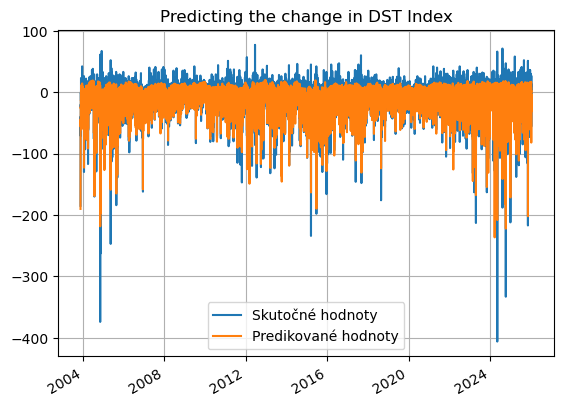

In [17]:
df = pd.DataFrame(data={"time": test['time1'][n_input:],"y_true": y_test[n_input:] , "y_predict": y_pred.reshape(-1)})

df["residuals"] = df["y_true"] - df["y_predict"]
df["true_binary"] = (df["y_true"] <= -20).astype(int)
df["pred_binary"] = (df["y_predict"] <= CLASSIFICATION_THRESHOLD).astype(int)
df["y_persistence"] = df["y_true"].shift(shift)

plt.figure()
plt.title('Predicting the change in DST Index')
plt.plot(df['time'],df['y_true'], label='Skutočné hodnoty')
plt.plot(df['time'],df['y_predict'], label='Predikované hodnoty')
plt.legend()
plt.gcf().autofmt_xdate()
plt.grid(True)

In [18]:
TN, FP, FN, TP = cm.ravel()
ACC = (TP + TN) / (TP + TN + FP + FN)
MCC = matthews_corrcoef(y_pred_binary_lstm, y_test_binary)
print("ACC={}".format(ACC))
print("MCC={}".format(MCC))
df['y_persistance'] = df['y_true'].shift(shift)
df = df.dropna(subset=["y_true", "y_predict", "y_persistance"])

# Získame hodnoty zo stĺpcov
y_true = df["y_true"].values
y_pred_nn = df["y_predict"].values
y_pred_persistence = df["y_persistance"].values

# MAE a MSE pre neurónovú sieť
mae_nn = mean_absolute_error(y_true, y_pred_nn)
mse_nn = mean_squared_error(y_true, y_pred_nn)

# MAE a MSE pre perzistentný model
mae_persistence = mean_absolute_error(y_true, y_pred_persistence)
mse_persistence = mean_squared_error(y_true, y_pred_persistence)

# Porovnanie zlepšenia
improvement_mae = (mae_persistence - mae_nn) / mae_persistence * 100
improvement_mse = (mse_persistence - mse_nn) / mse_persistence * 100

# Výpis
print("Výkon NN:")
print(f"MAE: {mae_nn:.4f}, MSE: {mse_nn:.4f}")

print("Perzistentný model:")
print(f"MAE: {mae_persistence:.4f}, MSE: {mse_persistence:.4f}")

print("Zlepšenie oproti Persistence Modelu:")
print(f"MAE Improvement: {improvement_mae:.2f}%")
print(f"MSE Improvement: {improvement_mse:.2f}%")

ACC=0.8921154559314352
MCC=0.6640133574492152
Výkon NN:
MAE: 6.4007, MSE: 103.2702
Perzistentný model:
MAE: 7.1853, MSE: 131.1014
Zlepšenie oproti Persistence Modelu:
MAE Improvement: 10.92%
MSE Improvement: 21.23%


In [19]:
###########################################
# 1. LSTM predikcie (aligned s n_input)
###########################################

y_train_lstm = model.predict(train_generator).reshape(-1)
y_val_lstm   = model.predict(val_generator).reshape(-1)
y_test_lstm  = model.predict(test_generator).reshape(-1)

# aligned y_true (TimeseriesGenerator posúva o n_input)
y_train_true = y_train[n_input:]
y_val_true   = y_val[n_input:]
y_test_true  = y_test[n_input:]

print("Shapes LSTM:")
print("train:", y_train_lstm.shape, y_train_true.shape)
print("val:  ", y_val_lstm.shape,   y_val_true.shape)
print("test: ", y_test_lstm.shape,  y_test_true.shape)


###########################################
# 2. Reziduá (chyba LSTM)
###########################################

error_train = y_train_true - y_train_lstm
error_val   = y_val_true   - y_val_lstm

# globálna smerodajná odchýlka chýb (použijeme ju na "nafúknutie" intervalu)
sigma_global = np.std(np.concatenate([error_train, error_val]))
print("Global sigma (LSTM errors):", sigma_global)


###########################################
# 3. Vstupy pre GP (tie isté indexy ako reziduá)
###########################################

X_train_seq = X_train[n_input:]   # rovnako dlhé ako y_train_lstm
X_val_seq   = X_val[n_input:]
X_test_seq  = X_test[n_input:]

# Spojenie train+val pre GP
X_gp_train = np.concatenate([X_train_seq, X_val_seq])
y_gp_train = np.concatenate([error_train, error_val])

X_test_gp = X_test_seq

print("Shapes GP:")
print("X_gp_train:", X_gp_train.shape)
print("y_gp_train:", y_gp_train.shape)
print("X_test_gp:", X_test_gp.shape)


###########################################
# 4. Gaussian Process (subsampling kvôli RAM)
###########################################

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

max_gp_points = 5000
if len(X_gp_train) > max_gp_points:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_gp_train), size=max_gp_points, replace=False)
    X_gp_sub = X_gp_train[idx]
    y_gp_sub = y_gp_train[idx]
    print(f"Using subsample of {len(X_gp_sub)} points for GP.")
else:
    X_gp_sub = X_gp_train
    y_gp_sub = y_gp_train
    print("Using all points for GP.")

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=20.0, length_scale_bounds=(1e-1, 1e3)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,
    normalize_y=True,
    n_restarts_optimizer=2,
    random_state=42
)

print("Training GP on", len(X_gp_sub), "points...")
gp.fit(X_gp_sub, y_gp_sub)
print("GP fitted. Kernel:", gp.kernel_)


###########################################
# 5. Predikcia GP chyby + hybrid LSTM+GP
###########################################

y_gp_mean_err, y_gp_std_err = gp.predict(X_test_gp, return_std=True)

y_hybrid_mean  = y_test_lstm + y_gp_mean_err

times_test = pd.to_datetime(test["time1"].iloc[n_input:]) 
sigma_series = pd.Series(y_gp_std_err, index=times_test)
sigma_smooth = sigma_series.rolling(window=6, center=True, min_periods=1).mean().values

sigma_effective = np.sqrt(sigma_smooth**2 + sigma_global**2)

#z = 1.96  # 95% interval
z = 3  # 99% interval
y_hybrid_lower = y_hybrid_mean - z * sigma_effective
y_hybrid_upper = y_hybrid_mean + z * sigma_effective

print("Hybrid prediction with smoothed, inflated interval ready.")

  1/896 ━━━━━━━━━━━━━━━━━━━━ 1:08 77ms/step

  2/896 ━━━━━━━━━━━━━━━━━━━━ 1:02 69ms/step

/opt/conda/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  3/896 ━━━━━━━━━━━━━━━━━━━━ 1:02 70ms/step

  4/896 ━━━━━━━━━━━━━━━━━━━━ 1:02 70ms/step

...

759/759 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step


Shapes LSTM:
train: (229308,) (229308,)
val:   (57291,) (57291,)
test:  (194152,) (194152,)
Global sigma (LSTM errors): 12.073329129588213
Shapes GP:
X_gp_train: (286599, 2)
y_gp_train: (286599,)
X_test_gp: (194152, 2)


Using subsample of 5000 points for GP.
Training GP on 5000 points...


GP fitted. Kernel: 2.51**2 * RBF(length_scale=30.1) + WhiteKernel(noise_level=0.87)


Hybrid prediction with smoothed, inflated interval ready.


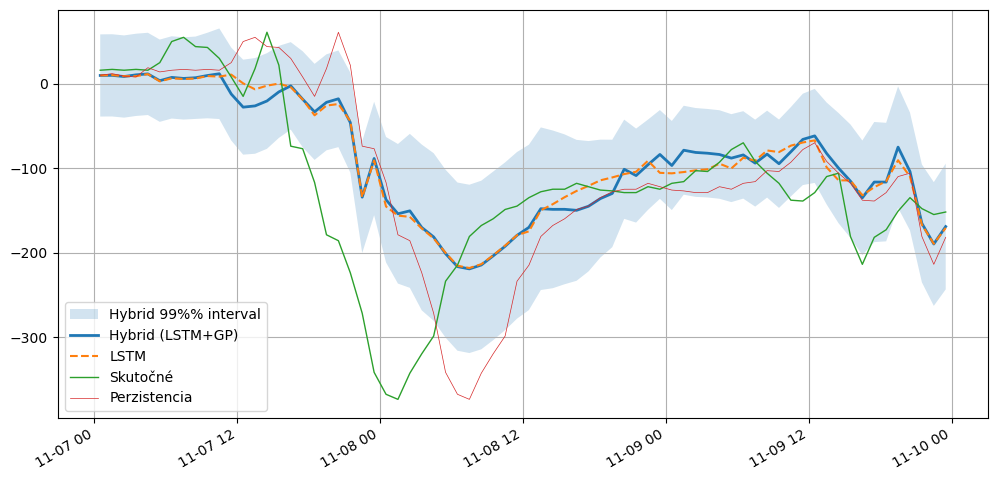

In [20]:
time_aligned = test["time1"][n_input:][shift:]

cols = [
    y_test_true[shift:],
    y_test_lstm[shift:],
    y_gp_mean_err[shift:],
    y_hybrid_mean[shift:],
    y_hybrid_lower[shift:],
    y_hybrid_upper[shift:],
    y_pred_persistence,
    time_aligned
]

L = min(len(x) for x in cols)

df = pd.DataFrame({
    "time": time_aligned[:L],
    "y_true": y_test_true[shift:][:L],
    "y_lstm": y_test_lstm[shift:][:L],
    "y_gp_error": y_gp_mean_err[shift:][:L],
    "y_hybrid": y_hybrid_mean[shift:][:L],
    "hybrid_lower": y_hybrid_lower[shift:][:L],
    "hybrid_upper": y_hybrid_upper[shift:][:L],
    "y_pred_persistence": y_pred_persistence[:L],
})




start_date = "2004-11-07"
end_date   = "2004-11-10"

df_range = df[(df["time"] >= start_date) & (df["time"] <= end_date)]

plt.figure(figsize=(12,6))
plt.fill_between(df_range["time"], df_range["hybrid_lower"], df_range["hybrid_upper"],
                 alpha=0.2, label="Hybrid 99%% interval")
plt.plot(df_range["time"], df_range["y_hybrid"], label="Hybrid (LSTM+GP)", linewidth=2)
plt.plot(df_range["time"], df_range["y_lstm"], label="LSTM", linestyle="--")
plt.plot(df_range["time"], df_range["y_true"], label="Skutočné", linewidth=1)
plt.plot(df_range["time"], df_range["y_pred_persistence"], label="Perzistencia", linewidth=0.5 )
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()
df.to_csv(f"../../../vizualizacie/V/prediction_comparison_{y_col}_LSTM_{n_input}H.csv", index=False)

In [21]:
from sklearn.metrics import mean_absolute_error

# --- REGRESNÉ METRIKY ---
y_true_hybrid = df['y_true'].to_numpy()
y_pred_hybrid = df['y_hybrid'].to_numpy()

mse = mean_squared_error(y_true_hybrid, y_pred_hybrid)
mae = mean_absolute_error(y_true_hybrid, y_pred_hybrid)

# --- KLASIFIKAČNÉ METRIKY ---
CLASSIFICATION_THRESHOLD_PRED = CLASSIFICATION_THRESHOLD
y_true_binary = np.where(y_true_hybrid <= -20, 1, 0)
y_pred_binary = np.where(y_pred_hybrid <= CLASSIFICATION_THRESHOLD_PRED, 1, 0)

conf_matrix = confusion_matrix(y_true_binary, y_pred_binary)
mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

# --- VÝSTUP ---
print("--- Regresné metriky (Hybridný model) ---")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

print(f"\n--- Klasifikačné metriky (Prah: {CLASSIFICATION_THRESHOLD_PRED} nT) ---")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

print("\nKonfúzna matica (Confusion Matrix):")
print("          | Predikcia 0 | Predikcia 1")
print("---------------------------------")
print(f"Skutočná 0 | {conf_matrix[0, 0]:>11} | {conf_matrix[0, 1]:>11}")
print(f"Skutočná 1 | {conf_matrix[1, 0]:>11} | {conf_matrix[1, 1]:>11}")

print("\nClassification Report (Trieda 1 je Búrka):")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Trieda 0 (Normálna)', 'Trieda 1 (Búrka)']))

--- Regresné metriky (Hybridný model) ---
MSE: 106.2686
MAE: 6.4180

--- Klasifikačné metriky (Prah: -20.2 nT) ---
Matthews Correlation Coefficient (MCC): 0.6681

Konfúzna matica (Confusion Matrix):
          | Predikcia 0 | Predikcia 1
---------------------------------
Skutočná 0 |      143911 |        8128
Skutočná 1 |       12974 |       29128

Classification Report (Trieda 1 je Búrka):
                     precision    recall  f1-score   support

Trieda 0 (Normálna)       0.92      0.95      0.93    152039
   Trieda 1 (Búrka)       0.78      0.69      0.73     42102

           accuracy                           0.89    194141
          macro avg       0.85      0.82      0.83    194141
       weighted avg       0.89      0.89      0.89    194141



In [22]:
import os, json
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, matthews_corrcoef, classification_report
)

OUT_CSV = "all_models_report.csv"

TRUE_CLASS_THRESHOLD = -20.0

PRED_CLASS_THRESHOLD = float(CLASSIFICATION_THRESHOLD)

meta = {
    "input_len_hours": float(globals().get("n_input", np.nan)),
    "forecast_horizon_hours": float(globals().get("shift", np.nan)),
    "target": str(globals().get("y_col", "DST")),
    "dataset": str(globals().get("dataset_name", "OMNI2_all")),
}

def _reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return (
        float(mean_absolute_error(y_true[m], y_pred[m])),
        float(mean_squared_error(y_true[m], y_pred[m]))
    )

def _cls_metrics_from_dst(y_true_dst, y_pred_dst, true_thr, pred_thr):
    y_true_dst = np.asarray(y_true_dst).reshape(-1)
    y_pred_dst = np.asarray(y_pred_dst).reshape(-1)
    m = np.isfinite(y_true_dst) & np.isfinite(y_pred_dst)

    y_true_bin = (y_true_dst[m] <= true_thr).astype(int)
    y_pred_bin = (y_pred_dst[m] <= pred_thr).astype(int)

    acc = float(accuracy_score(y_true_bin, y_pred_bin))
    mcc = float(matthews_corrcoef(y_true_bin, y_pred_bin))
    rep = classification_report(y_true_bin, y_pred_bin, digits=4, zero_division=0)
    return acc, mcc, rep

def _improvement(model_err, base_err):
    return float(100.0 * (base_err - model_err) / base_err) if base_err != 0 else np.nan

def _append_row(csv_path, row):
    row_df = pd.DataFrame([row])
    if os.path.exists(csv_path):
        old = pd.read_csv(csv_path)
        out = pd.concat([old, row_df], ignore_index=True)
    else:
        out = row_df
    out.to_csv(csv_path, index=False)
    return out

required_cols = {"y_true", "y_lstm", "y_hybrid", "y_pred_persistence"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"df nemá potrebné stĺpce: {missing}. Aktuálne: {list(df.columns)}")

df_eval = df.dropna(subset=list(required_cols)).copy()

def log_one_model(nn_type, y_pred_col):
    y_true = df_eval["y_true"].to_numpy(dtype=float)
    y_pred = df_eval[y_pred_col].to_numpy(dtype=float)
    y_pers = df_eval["y_pred_persistence"].to_numpy(dtype=float)

    mae_model, mse_model = _reg_metrics(y_true, y_pred)
    mae_pers,  mse_pers  = _reg_metrics(y_true, y_pers)

    mae_imp = _improvement(mae_model, mae_pers)
    mse_imp = _improvement(mse_model, mse_pers)

    acc, mcc, rep_txt = _cls_metrics_from_dst(
        y_true, y_pred,
        true_thr=TRUE_CLASS_THRESHOLD,
        pred_thr=PRED_CLASS_THRESHOLD
    )

    row = {
        "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
        "nn_type": nn_type,  # LSTM vs LSTM+GP

        # meta
        **meta,

        # prahy
        "true_class_threshold_nt": float(TRUE_CLASS_THRESHOLD),
        "pred_class_threshold_nt": float(PRED_CLASS_THRESHOLD),

        # klasifikácia
        "ACC": float(acc),
        "MCC": float(mcc),
        "classification_report": json.dumps({"text": rep_txt}, ensure_ascii=False),

        # regresia
        "MAE_model": float(mae_model),
        "MSE_model": float(mse_model),
        "MAE_persistence": float(mae_pers),
        "MSE_persistence": float(mse_pers),
        "MAE_improvement_pct": float(mae_imp),
        "MSE_improvement_pct": float(mse_imp),
    }

    print(f"\n===== {nn_type} =====")
    print(f"ACC={row['ACC']}")
    print(f"MCC={row['MCC']}")
    print("Výkon NN:")
    print(f"MAE: {row['MAE_model']:.4f}, MSE: {row['MSE_model']:.4f}")
    print("Perzistentný model:")
    print(f"MAE: {row['MAE_persistence']:.4f}, MSE: {row['MSE_persistence']:.4f}")
    print("Zlepšenie oproti Persistence Modelu:")
    print(f"MAE Improvement: {row['MAE_improvement_pct']:.2f}%")
    print(f"MSE Improvement: {row['MSE_improvement_pct']:.2f}%")
    print("\nKlasifikačný report:")
    print(rep_txt)

    return row

rows = [
    log_one_model("LSTM", "y_lstm"),
    log_one_model("LSTM+GP", "y_hybrid"),
]

out_df = None
for r in rows:
    out_df = _append_row(OUT_CSV, r)

print(f"\nSaved/updated: {OUT_CSV}")
out_df.tail(10)


===== LSTM =====
ACC=0.8921093432093169
MCC=0.6639690743517788
Výkon NN:
MAE: 6.4007, MSE: 103.2702
Perzistentný model:
MAE: 7.1853, MSE: 131.1014
Zlepšenie oproti Persistence Modelu:
MAE Improvement: 10.92%
MSE Improvement: 21.23%

Klasifikačný report:
              precision    recall  f1-score   support

           0     0.9086    0.9587    0.9330    152039
           1     0.8138    0.6516    0.7237     42102

    accuracy                         0.8921    194141
   macro avg     0.8612    0.8051    0.8283    194141
weighted avg     0.8880    0.8921    0.8876    194141


===== LSTM+GP =====
ACC=0.891305803513941
MCC=0.6680697354014724
Výkon NN:
MAE: 6.4180, MSE: 106.2686
Perzistentný model:
MAE: 7.1853, MSE: 131.1014
Zlepšenie oproti Persistence Modelu:
MAE Improvement: 10.68%
MSE Improvement: 18.94%

Klasifikačný report:
              precision    recall  f1-score   support

           0     0.9173    0.9465    0.9317    152039
           1     0.7818    0.6918    0.7341     4210

/tmp/ipykernel_141006/2496226351.py:83: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),
/tmp/ipykernel_141006/2496226351.py:83: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.utcnow().isoformat(timespec="seconds"),


,timestamp_utc,nn_type,input_len_hours,forecast_horizon_hours,target,dataset,true_class_threshold_nt,pred_class_threshold_nt,ACC,MCC,classification_report,MAE_model,MSE_model,MAE_persistence,MSE_persistence,MAE_improvement_pct,MSE_improvement_pct
84,2026-04-16T22:37:44,LSTM,24.0,6.0,DST+6,OMNI2_all,-20.0,-20.1,0.891489,0.663448,"{""text"": "" precision recall f...",6.299794,106.309178,7.203240,134.989823,12.542209,21.246524
85,2026-04-16T22:37:44,LSTM+GP,24.0,6.0,DST+6,OMNI2_all,-20.0,-20.1,0.890444,0.664463,"{""text"": "" precision recall f...",6.420918,108.476302,7.203240,134.989823,10.860685,19.641126
86,2026-04-16T22:47:39,LSTM,30.0,6.0,DST+6,OMNI2_all,-20.0,-19.3,0.891944,0.663974,"{""text"": "" precision recall f...",6.452199,108.449272,7.200598,134.630519,10.393570,19.446740
87,2026-04-16T22:47:39,LSTM+GP,30.0,6.0,DST+6,OMNI2_all,-20.0,-19.3,0.890718,0.669219,"{""text"": "" precision recall f...",6.474193,108.540502,7.200598,134.630519,10.088122,19.378977
88,2026-04-16T22:56:43,LSTM,36.0,6.0,DST+6,OMNI2_all,-20.0,-19.3,0.891328,0.662867,"{""text"": "" precision recall f...",6.406359,106.481924,7.192498,132.305857,10.929984,19.518359
89,2026-04-16T22:56:43,LSTM+GP,36.0,6.0,DST+6,OMNI2_all,-20.0,-19.3,0.888778,0.665910,"{""text"": "" precision recall f...",6.545559,111.191333,7.192498,132.305857,8.994633,15.958873
90,2026-04-16T23:06:13,LSTM,42.0,6.0,DST+6,OMNI2_all,-20.0,-20.0,0.892180,0.667946,"{""text"": "" precision recall f...",6.262506,101.299402,7.188125,131.449474,12.877061,22.936624
91,2026-04-16T23:06:13,LSTM+GP,42.0,6.0,DST+6,OMNI2_all,-20.0,-20.0,0.890660,0.671596,"{""text"": "" precision recall f...",6.397771,105.389375,7.188125,131.449474,10.995274,19.825183
92,2026-04-16T23:16:21,LSTM,48.0,6.0,DST+6,OMNI2_all,-20.0,-20.2,0.892109,0.663969,"{""text"": "" precision recall f...",6.400676,103.270165,7.185324,131.101406,10.920144,21.228789
93,2026-04-16T23:16:21,LSTM+GP,48.0,6.0,DST+6,OMNI2_all,-20.0,-20.2,0.891306,0.668070,"{""text"": "" precision recall f...",6.417961,106.268600,7.185324,131.101406,10.679595,18.941678
